# **Single-Neuron Network with and without PCA**
Course: Artificial Intelligence II                      
Lecturer: Dr Andrés Hernández Gutiérrez                      
Due date: Thursday 5 March 2026, 11:59pm

*Mariana Samperio Cuevas • 639835*                         
*Camila Johana Gonzalez Acosta • 599303*           
*Matteo Peroni Pecci • 689789*



A single-neuron network represents the most fundamental unit of an artificial neural network and serves as a foundational model for binary classification problems. It computes a weighted
linear combination of input features and applies an activation function to produce an output that can be interpreted as a class prediction or probability score.

For this assignment we will be using the dataset [Bank Transaction Fraud Detection](https://www.kaggle.com/datasets/marusagar/bank-transaction-fraud-detection) from Kaggle.

The dataset includes the following variables:

- Customer_ID: A particular identifier for every customer within the bank's system.
- Customer_Name: The name of the consumer making the transaction.
- Gender: The gender of the consumer (e.G., Male, Female, Other).

- Age: The age of the consumer at the time of the transaction.
- State: The nation in which the patron resides.
- City: The metropolis wherein the client is living.
- Bank_Branch: The specific financial institution branch wherein the consumer holds their account.

- Account_Type: The kind of account held with the aid of the customer (e.G., Savings, Checking).

- Transaction_ID: A particular identifier for each transaction.
- Transaction_Date: The date on which the transaction passed off.
- Transaction_Time: The specific time the transaction became initiated.
- Transaction_Amount: The financial value of the transaction.
- Merchant_ID: A particular identifier for the merchant worried within the transaction.
- Transaction_Type: The nature of the transaction (e.G., Withdrawal, Deposit, Transfer).
- Merchant_Category: The class of the merchant (e.G., Retail, Online, Travel).
- Account_Balance: The balance of the customer's account after the transaction.
- Transaction_Device: The tool utilized by the consumer to perform the transaction (e.G., Mobile, Desktop).
- Transaction_Location: The geographical vicinity (e.G., latitude, longitude) of the transaction.
- Device_Type: The kind of device used for the transaction (e.G., Smartphone, Laptop).
- Transaction_Currency: The currency used for the transaction (e.G., USD, EUR).
- Customer_Contact: The contact variety of the client.
- Transaction_Description: A brief description of the transaction (e.G., buy, switch).
- Customer_Email: The e-mail cope with related to the consumer's account.
- Is_Fraud: A binary indicator (1 or zero) indicating whether or not the transaction is fraudulent or now not. (TARGET)



**Import of libraries**

In [ ]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
!pip install scikit-optimize
from skopt import BayesSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.under_sampling import RandomUnderSampler

**Data preprocesing and EDA**

In [ ]:
dataset = pd.read_csv('/content/dataset.csv')
dataset

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,b8bdae19-296f-48b7-9104-e055d33a09ac,Vedhika Magar,Female,55,Dadra and Nagar Haveli and Daman and Diu,Diu,Diu Branch,Business,8d856bc7-4666-4509-a067-48d67500694a,08-01-2025,...,Restaurant,37475.11,Desktop/Laptop,"Diu, Dadra and Nagar Haveli and Daman and Diu",ATM,0,INR,+9192629XXXXXX,ATM withdrawal,vedhikaXXXXX@XXXXXXX.com
199996,635bc099-8a93-48ee-829a-bf2283fe8fda,Aashi Pai,Male,51,Manipur,Kangpokpi,Kangpokpi Branch,Business,f2890dbd-4e01-445d-97f5-ac56886e9037,01-01-2025,...,Groceries,53037.20,ATM,"Kangpokpi, Manipur",ATM,0,INR,+9198116XXXXXX,Subscription box,aashiXXX@XXXXXX.com
199997,c1b31cc2-0905-47e8-8cc5-6461d1f3ba33,Dayita Shan,Female,41,Chandigarh,Chandigarh,Chandigarh Branch,Savings,f714b758-7539-474d-b676-5fa7e2480141,28-01-2025,...,Health,96225.36,ATM,"Chandigarh, Chandigarh",Desktop,0,INR,+9192601XXXXXX,Charity donation,dayitaXXXX@XXXXXXX.com
199998,32bb8e66-f3fa-43bf-8242-dab9a6116310,Unnati Vyas,Female,28,Telangana,Nizamabad,Nizamabad Branch,Checking,f6903b6a-b582-47ea-95d5-aff16bdec950,08-01-2025,...,Electronics,89599.90,Voice Assistant,"Nizamabad, Telangana",Desktop,0,INR,+9197537XXXXXX,Tourist attraction payment,unnatiXXX@XXXXX.com


We will examine the data types and look for missing values, as shown on the next two lines of code:

In [ ]:
dataset.dtypes

,0
Customer_ID,object
Customer_Name,object
Gender,object
Age,int64
State,object
City,object
Bank_Branch,object
Account_Type,object
Transaction_ID,object
Transaction_Date,object


In [ ]:
dataset.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
Gender,0
Age,0
State,0
City,0
Bank_Branch,0
Account_Type,0
Transaction_ID,0
Transaction_Date,0


luckily, there aren't any missing values on our database.

We will now check for bool variables and find out where we can apply One Hot and Label Encoding

In [ ]:
for column in dataset.columns:
    print(f"Column '{column}': {dataset[column].nunique()} unique values")

Column 'Customer_ID': 200000 unique values
Column 'Customer_Name': 142699 unique values
Column 'Gender': 2 unique values
Column 'Age': 53 unique values
Column 'State': 34 unique values
Column 'City': 145 unique values
Column 'Bank_Branch': 145 unique values
Column 'Account_Type': 3 unique values
Column 'Transaction_ID': 200000 unique values
Column 'Transaction_Date': 31 unique values
Column 'Transaction_Time': 77856 unique values
Column 'Transaction_Amount': 197978 unique values
Column 'Merchant_ID': 200000 unique values
Column 'Transaction_Type': 5 unique values
Column 'Merchant_Category': 6 unique values
Column 'Account_Balance': 197954 unique values
Column 'Transaction_Device': 20 unique values
Column 'Transaction_Location': 148 unique values
Column 'Device_Type': 4 unique values
Column 'Is_Fraud': 2 unique values
Column 'Transaction_Currency': 1 unique values
Column 'Customer_Contact': 9000 unique values
Column 'Transaction_Description': 172 unique values
Column 'Customer_Email': 4

After checking, we will be using Label Encoding to variables that have less than 6 unique values. We will also be deleting categorical variables and transforming date and time so we can use the month and hour the transaction happens.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

dataset = pd.read_csv('/content/dataset.csv')

dataset = dataset.drop(columns=[
'Customer_ID',
'Customer_Name',
'State',
'City',
'Bank_Branch',
'Transaction_ID',
'Merchant_ID',
'Transaction_Device',
'Transaction_Location',
'Transaction_Currency',
'Customer_Contact',
'Transaction_Description',
'Customer_Email'
])

dataset['Transaction_Date'] = pd.to_datetime(dataset['Transaction_Date'], format='%d-%m-%Y')
dataset['Month'] = dataset['Transaction_Date'].dt.month

dataset['Transaction_Time'] = pd.to_datetime(dataset['Transaction_Time'], format='%H:%M:%S')
dataset['Hour'] = dataset['Transaction_Time'].dt.hour

dataset['Hour_sin'] = np.sin(2 * np.pi * dataset['Hour'] / 24)
dataset['Hour_cos'] = np.cos(2 * np.pi * dataset['Hour'] / 24)

dataset['Month_sin'] = np.sin(2 * np.pi * dataset['Month'] / 12)
dataset['Month_cos'] = np.cos(2 * np.pi * dataset['Month'] / 12)

# Apply Label Encoding to categorical columns
categorical_cols = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 'Device_Type']
le = LabelEncoder()
for col in categorical_cols:
    dataset[col] = le.fit_transform(dataset[col])

dataset = dataset.drop(columns=['Transaction_Date','Transaction_Time','Hour','Month'])

In [ ]:
dataset

,Gender,Age,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Device_Type,Is_Fraud,Hour_sin,Hour_cos,Month_sin,Month_cos
0,1,60,2,32415.45,3,5,74557.27,3,0,-8.660254e-01,-5.000000e-01,0.5,0.866025
1,0,51,0,43622.60,0,5,74622.66,1,0,-9.659258e-01,-2.588190e-01,0.5,0.866025
2,1,20,2,63062.56,0,3,66817.99,1,0,7.071068e-01,7.071068e-01,0.5,0.866025
3,0,57,0,14000.72,2,2,58177.08,2,0,1.224647e-16,-1.000000e+00,0.5,0.866025
4,0,43,2,18335.16,3,2,16108.56,2,0,-1.000000e+00,-1.836970e-16,0.5,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,0,55,0,98513.74,1,5,37475.11,0,0,-1.000000e+00,-1.836970e-16,0.5,0.866025
199996,1,51,0,40593.55,4,3,53037.20,0,0,-8.660254e-01,5.000000e-01,0.5,0.866025
199997,0,41,2,61579.70,4,4,96225.36,1,0,5.000000e-01,-8.660254e-01,0.5,0.866025
199998,0,28,1,39488.22,2,1,89599.90,1,0,1.000000e+00,6.123234e-17,0.5,0.866025


Now we will proceed to do EDA.
First we wanna see the objet variable's dsitribution

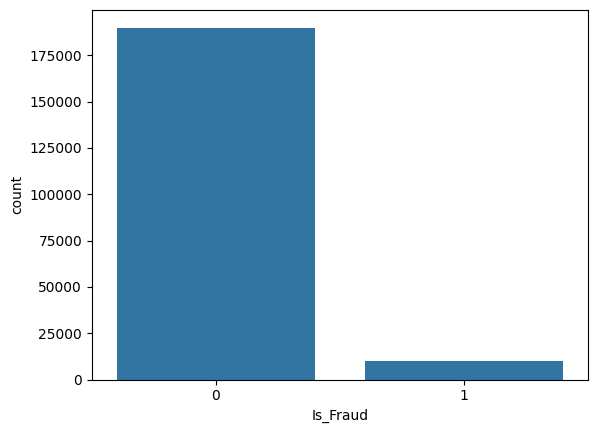

,proportion
Is_Fraud,
0,94.956
1,5.044


In [ ]:
sns.countplot(x='Is_Fraud', data=dataset)
plt.show()

dataset['Is_Fraud'].value_counts(normalize=True) * 100

Now we will plot the covariance matrix in this next block of code:

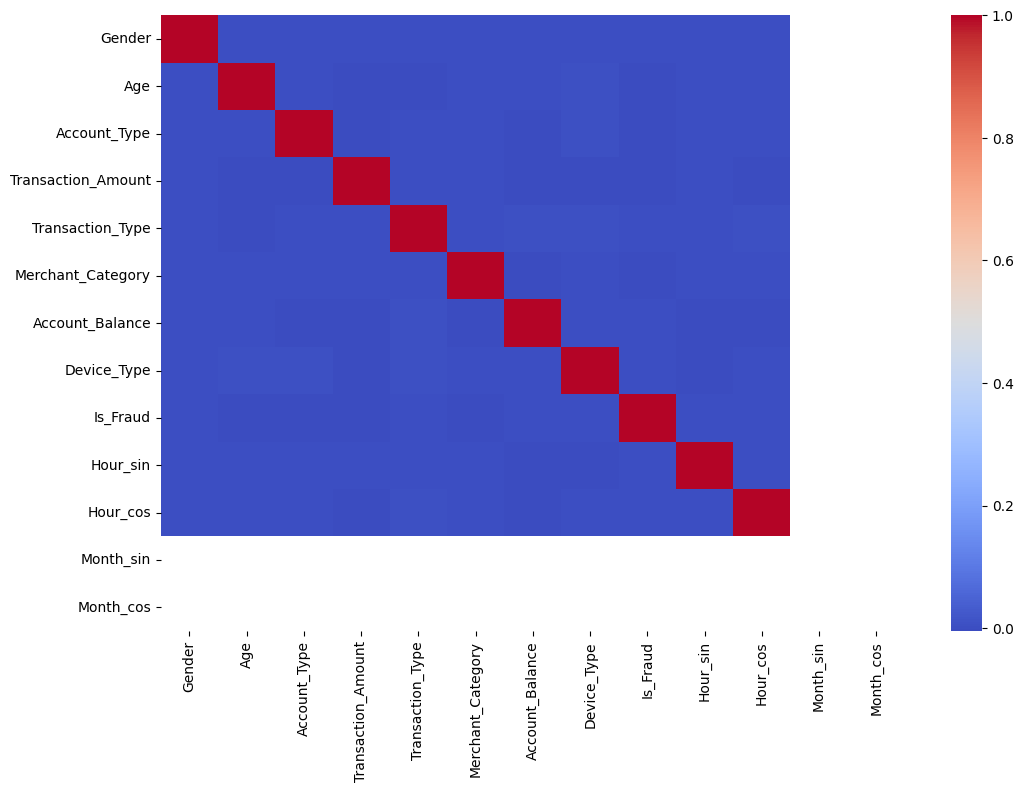

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.corr(), annot=False, cmap='coolwarm')
plt.show()

Finally, we will check:

*   Fraud by hour of the day
*   Fraud by account type
*   Fraud by device type


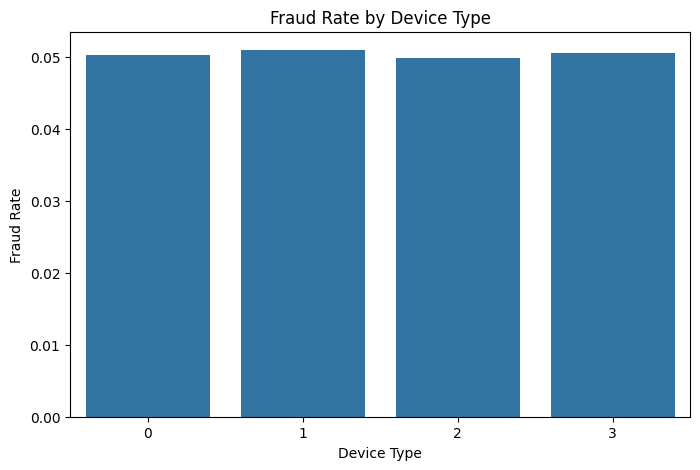

In [ ]:
fraud_by_device = dataset.groupby('Device_Type')['Is_Fraud'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=fraud_by_device.index, y=fraud_by_device.values)
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Device Type")
plt.show()

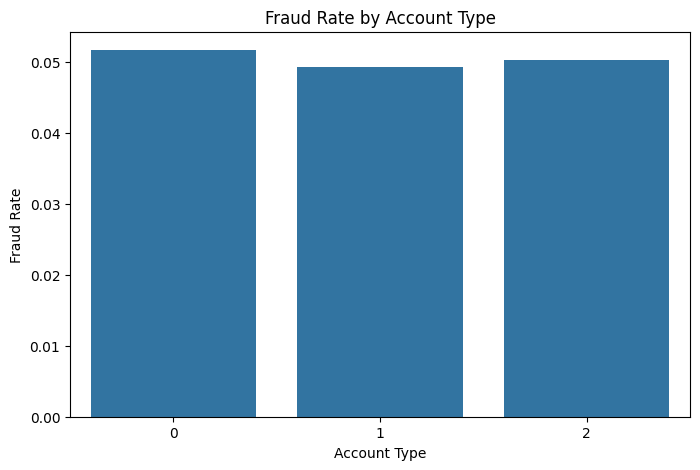

In [ ]:
fraud_by_account = dataset.groupby('Account_Type')['Is_Fraud'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=fraud_by_account.index, y=fraud_by_account.values)
plt.xlabel("Account Type")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Account Type")
plt.show()

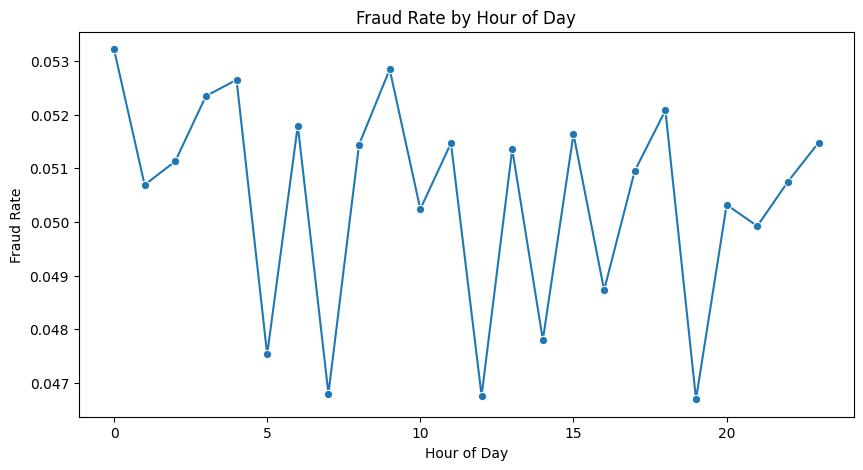

In [ ]:
dataset['Hour'] = (np.arctan2(dataset['Hour_sin'], dataset['Hour_cos']) * 24 / (2*np.pi)) % 24
dataset['Hour'] = dataset['Hour'].round().astype(int)

fraud_by_hour = dataset.groupby('Hour')['Is_Fraud'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=fraud_by_hour.index, y=fraud_by_hour.values, marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour of Day")
plt.show()

In [ ]:
dataset.head()

,Gender,Age,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Device_Type,Is_Fraud,Hour_sin,Hour_cos,Month_sin,Month_cos,Hour
0,1,60,2,32415.45,3,5,74557.27,3,0,-8.660254e-01,-5.000000e-01,0.5,0.866025,16
1,0,51,0,43622.60,0,5,74622.66,1,0,-9.659258e-01,-2.588190e-01,0.5,0.866025,17
2,1,20,2,63062.56,0,3,66817.99,1,0,7.071068e-01,7.071068e-01,0.5,0.866025,3
3,0,57,0,14000.72,2,2,58177.08,2,0,1.224647e-16,-1.000000e+00,0.5,0.866025,12
4,0,43,2,18335.16,3,2,16108.56,2,0,-1.000000e+00,-1.836970e-16,0.5,0.866025,18


In [ ]:
def create_single_neuron_model(input_shape, activation='sigmoid', learning_rate=0.01):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(1, activation=activation)
    ])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

**Model design and training**

In [ ]:
# Undersampling
from tensorflow.keras.callbacks import EarlyStopping
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


# Separate features (X) and target (y)
X = dataset.drop('Is_Fraud', axis=1)
y = dataset['Is_Fraud']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Random UnderSampler to balance the training data
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(x_train, y_train)

print("Undersampling class distributions:")
print(pd.Series(y_train_resampled).value_counts())

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(x_test) # Scale the test set using the same scaler fitted on the training data

# Model creation: input_shape is now derived from the scaled training data
model_p1_undersampled = create_single_neuron_model(input_shape=X_train_scaled.shape[1], activation='sigmoid', learning_rate=0.01)
model_p1_undersampled.summary()

# Train the model with EarlyStopping callback
history_undersampled = model_p1_undersampled.fit(
    X_train_scaled, y_train_resampled,
    epochs=20,
    validation_data=(X_test_scaled, y_test), # Use the correctly processed and scaled test data
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

Undersampling class distributions:
Is_Fraud
0    8043
1    8043
Name: count, dtype: int64


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4981 - loss: 0.7370 - val_accuracy: 0.4020 - val_loss: 0.7146
Epoch 2/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5029 - loss: 0.6954 - val_accuracy: 0.4965 - val_loss: 0.6964
Epoch 3/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4926 - loss: 0.6970 - val_accuracy: 0.3981 - val_loss: 0.7089
Epoch 4/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4934 - loss: 0.6962 - val_accuracy: 0.2313 - val_loss: 0.7225
Epoch 5/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4987 - loss: 0.6962 - val_accuracy: 0.5349 - val_loss: 0.6902
Epoch 6/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4944 - loss: 0.6957 - val_accuracy: 0.2677 - val_loss: 0.7292
Epoch 7/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4988 - loss: 0.6956 - val_accuracy: 0.4913 - val_loss: 0.6996
Epoch 8/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4956 - loss: 0.6966 - val_accuracy: 

Use of undersampling:
Random undersampling was used because the dataset is highly imbalanced, with many more non-fraud transactions than fraud cases. This imbalance can cause the model to become biased toward predicting the majority class. RandomUnderSampler works by randomly removing examples from the majority class in the training data until both classes have a similar number of samples. This helps the model learn patterns from the minority class (fraud) more effectively and improves its ability to detect positive cases.

**Learning Curve Anslysis**

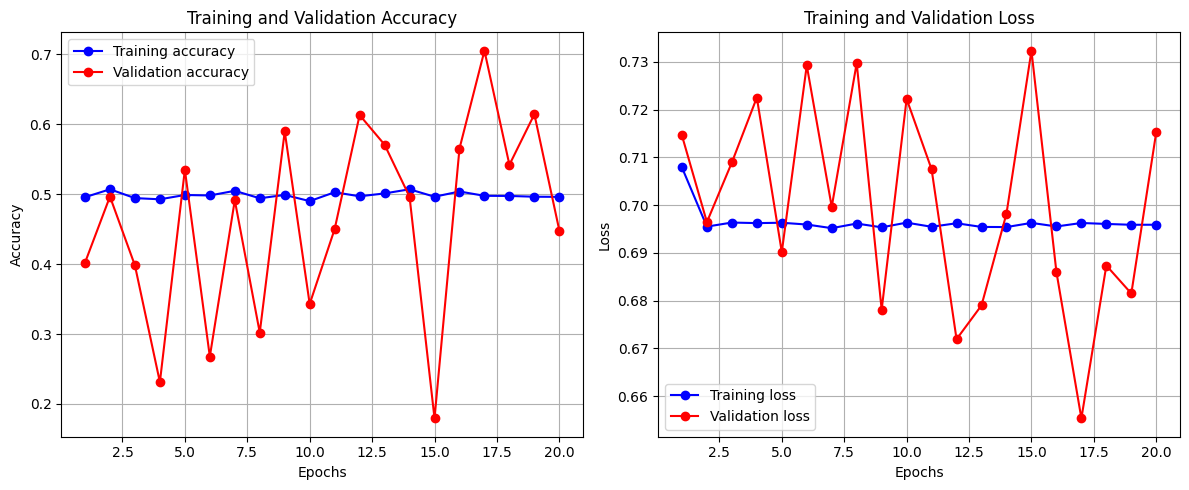

In [ ]:
def plot_training_history(history):
    """
    Generates two plots: one for training/validation accuracy and one for training/validation loss
    over epochs.

    Args:
        history (keras.callbacks.History): The history object returned by the model's fit method.
    """
    # Extraction of relevant data for the plotting function
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Plot training and talidation accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_training_history(history_undersampled)


The model shows underfitting. The training accuracy stays low (around 0.50) and the training loss remains high and almost constant, indicating the model is not learning strong patterns from the data. The validation accuracy and loss fluctuate but do not show clear improvement. Since both training and validation performance are relatively poor and similar, this suggests the model is not complex enough or has not learned enough from the data.

**Model Evaluation and Testing Data**

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step

--- Evaluation with Random UnderSampling ---

Confusion Matrix (values):
[[16792 21163]
 [  916  1129]]

Accuracy: 0.4480
Precision: 0.0506
Recall: 0.5521
Specificity: 0.4424
F1-score: 0.0928

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.44      0.60     37955
           1       0.05      0.55      0.09      2045

    accuracy                           0.45     40000
   macro avg       0.50      0.50      0.35     40000
weighted avg       0.90      0.45      0.58     40000



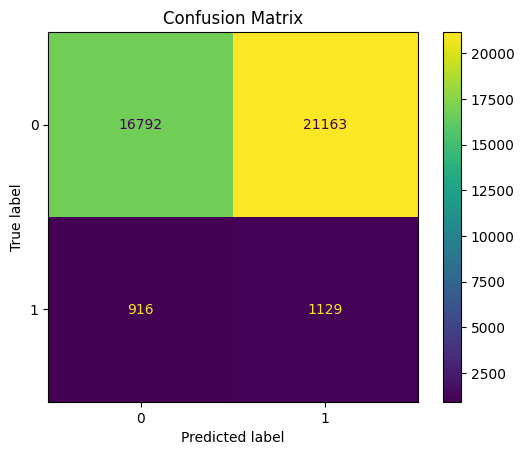

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
# Make predictions on the scaled test data
y_pred_proba_undersampled = model_p1_undersampled.predict(X_test_scaled)
y_pred_undersampled = (y_pred_proba_undersampled > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_undersampled)
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred_undersampled)
precision = precision_score(y_test, y_pred_undersampled)
recall = recall_score(y_test, y_pred_undersampled)
f1 = f1_score(y_test, y_pred_undersampled)

# Specificity
specificity = tn / (tn + fp)

print("\n--- Evaluation with Random UnderSampling ---")

print("\nConfusion Matrix (values):")
print(cm)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_undersampled))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In this model, recall is 0.44, meaning it detects around 44% of the true positive cases, but the precision is very low (0.05), indicating that most of the predicted positives are actually false positives. The specificity (0.55) shows the model correctly classifies just over half of the negative cases, and the F1-score (0.09) reflects the poor balance between precision and recall. Given these results, recall may be the most important metric if detecting positive cases is critical, but overall the model performance is not very acceptable, since it produces a very large number of false positives and only moderate detection of the positive class.

**Save Model**

In [ ]:
model_p1_undersampled.save("model.keras")

**PCA procedure**

In [ ]:
try:
    # 1. Apply PCA on the scaled data
    # Initialize PCA to retain 70% of the variance
    pca = PCA(n_components=0.70, random_state=42)

    # Fit PCA on the scaled and resampled training data and transform it
    X_train_pca = pca.fit_transform(X_train_scaled)

    # Transform the scaled test data using the PCA fitted on the training data
    X_test_pca = pca.transform(X_test_scaled)

    print(f"Number of components selected by PCA: {pca.n_components_}")

    # 2. Train a new model with the same parameters but using PCA-transformed data
    # Model creation: input_shape is now derived from the PCA-transformed training data
    model_p1_pca = create_single_neuron_model(input_shape=X_train_pca.shape[1], activation='sigmoid', learning_rate=0.01)
    model_p1_pca.summary()

    # Train the model with EarlyStopping callback
    history_pca = model_p1_pca.fit(
        X_train_pca, y_train_resampled, # Use PCA-transformed and undersampled training data
        epochs=20,
        validation_data=(X_test_pca, y_test), # Use PCA-transformed test data for validation
        callbacks=[EarlyStopping(patience=5)],
        verbose=1
    )

except Exception as e:
    print(f"An error occurred during PCA and model training: {e}")

Number of components selected by PCA: 7


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4998 - loss: 0.7664 - val_accuracy: 0.4568 - val_loss: 0.6996
Epoch 2/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4923 - loss: 0.6952 - val_accuracy: 0.6820 - val_loss: 0.6781
Epoch 3/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5118 - loss: 0.6944 - val_accuracy: 0.3665 - val_loss: 0.7138
Epoch 4/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4934 - loss: 0.6953 - val_accuracy: 0.4796 - val_loss: 0.6969
Epoch 5/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4960 - loss: 0.6950 - val_accuracy: 0.5222 - val_loss: 0.6913
Epoch 6/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5040 - loss: 0.6945 - val_accuracy: 0.5979 - val_loss: 0.6812
Epoch 7/20
503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5049 - loss: 0.6942 - val_accuracy: 0.6217 - val_loss: 0.6827


**Dimensionality Reduction and Redundancy**

PCA reduced the dataset to 7 principal components, meaning the original features were compressed into a smaller set that still retains most of the variance. This suggests that some redundancy existed among the original variables, since several features could be represented through fewer components.

**PCA results**

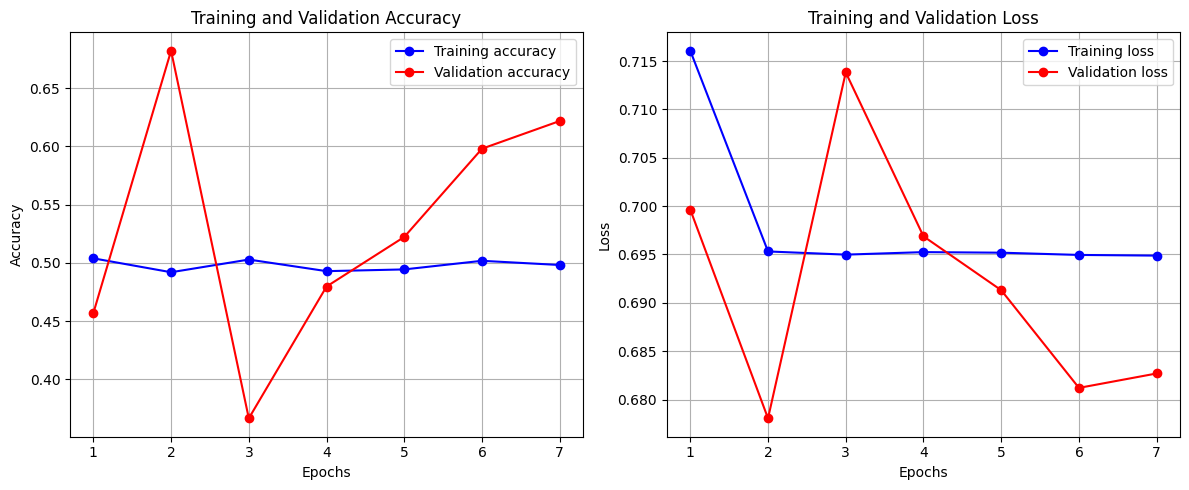

In [ ]:
#Learning curves
plot_training_history(history_pca)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 756us/step

--- Evaluation with Random UnderSampling ---

Confusion Matrix (values):
[[24138 13817]
 [ 1314   731]]

Accuracy: 0.6217
Precision: 0.0502
Recall: 0.3575
Specificity: 0.6360
F1-score: 0.0881

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.64      0.76     37955
           1       0.05      0.36      0.09      2045

    accuracy                           0.62     40000
   macro avg       0.50      0.50      0.42     40000
weighted avg       0.90      0.62      0.73     40000



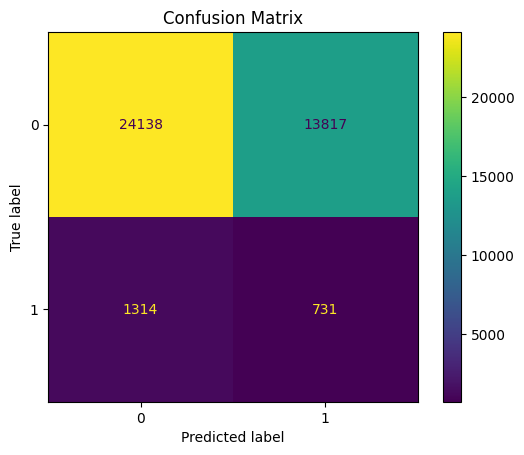

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
# Make predictions on the scaled test data
y_pred_proba_pca = model_p1_pca.predict(X_test_pca)
y_pred_pca = (y_pred_proba_pca > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_pca)
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred_pca)
precision = precision_score(y_test, y_pred_pca)
recall = recall_score(y_test, y_pred_pca)
f1 = f1_score(y_test, y_pred_pca)

# Specificity
specificity = tn / (tn + fp)

print("\n--- Evaluation with Random UnderSampling ---")

print("\nConfusion Matrix (values):")
print(cm)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Save the new model
model_p1_pca.save("model_pca.keras")

- **Why PCA Did Not Help:** Despite reducing dimensionality, PCA did not improve the model’s performance. Most of the original features have very low correlation with the target variable (`is_fraud`), and the few that correlate only provide a weak signal. Because of this, PCA mostly compresses features that were already not very informative, so removing part of this variance does not create a stronger predictive signal.

- **Model Performance Comparison:** The original-feature model achieved about 0.55 accuracy, 0.44 recall, and 0.54 specificity, while the PCA-based model dropped to around 0.41 accuracy and 0.39 specificity, although recall increased to about 0.60. Precision remained very low in both models (around 0.05), resulting in a similar F1-score (0.09).

- **Learning Behaviour and Stability:** The original model shows more stable learning, with relatively consistent training and validation curves. The PCA model shows larger fluctuations in validation accuracy and loss, suggesting less stable training.

- **Trade-off and Model Choice:** There is a trade-off between dimensionality reduction and predictive performance. While PCA simplifies the dataset, it reduces overall performance. For this reason, the original-feature model would be preferable for deployment, since it maintains better accuracy, specificity, and training stability.

**Personal Conclusions: Mariana**

**Conclusion**

This assignment helped me better understand how a single-neuron network can be used for a binary classification problem. By building and training the model, I learned how concepts like decision boundaries, loss functions, and gradient-based optimisation work in practice.

One thing I noticed is that single-neuron networks are simple and easy to understand, but they are also limited because they can only learn linear relationships. Because of this, they may not perform well when the data is more complex.

Using PCA showed how reducing the number of features can simplify the data and sometimes help the model train more efficiently. However, reducing dimensions can also remove useful information, so it does not always improve performance.

Finally it is worth noting that a limitation of this study is that we only used a very simple model and one dataset. The model’s performance could be improved in the future by testing more advanced neural networks, improving feature selection, or tuning the model’s parameters.


GitHub Repository: https://github.com/mariana-samperio-cuevas/SingleNeuron-Network-with-and-without-PCA.git

**Personal Conclusions: Camila**

This assignment helped me understand how a single-neuron network performs in a real classification problem with imbalanced data. One key lesson was that simple models can capture basic patterns, but their ability to learn complex relationships is limited. Even after applying undersampling, the model still struggled to achieve strong predictive performance, particularly in terms of precision.

Working with a single-neuron network showed that its learning capacity is restricted, since it only performs a linear combination of the inputs followed by a sigmoid activation. This makes it difficult for the model to capture more complex patterns that may exist in the data.

The use of PCA reduced the dataset to seven components, but it did not improve performance. Most of the original features had very weak correlation with the target variable, so PCA mainly compressed features that already contained little predictive information.

One limitation of this study is the simplicity of the model and the weak predictive signal in the dataset. To improve performance, future work could explore more complex models, other imbalance handling techniques such as class weighting, and additional feature engineering.

GitHub Repository: https://github.com/camilagzzaa/SingleNeuron-Network-with-and-without-PCA.git

**Personal Conclusions: Matteo**

Overall, this assignment helped me better understand how to build and experiment with a simple neural network for a fraud detection task using bank transaction data. I learned how to implement a neural network using the TensorFlow Sequential API and gained practical experience with the workflow of defining, training, and evaluating a model. A key challenge of this dataset was the strong class imbalance, which is typical in fraud detection. To address this, I explored the use of the class_weight module from scikit-learn to give more importance to the minority class, and through group research I also learned about downsampling techniques to balance the dataset. This helped me improve my understanding of dataset balancing strategies and their impact on model performance and accuracy.

One observation from this project is that the model’s performance could likely be improved through systematic hyperparameter optimization. In particular, Bayesian search could be useful because it explores the hyperparameter search space efficiently using a probabilistic approach. Additionally, since the model consisted of a single neuron, adding one or more hidden layers could allow the network to capture more complex patterns and features, potentially improving generalization, especially for the fraud class (is_fraud = 1).

Regarding PCA, the original features were weakly correlated with the target variable. After applying PCA and keeping 90% of the variance, the number of features was reduced from 19 to 11, but this did not improve the model’s performance, suggesting that dimensionality reduction did not add useful information for this task.

One limitation of the study is that hyperparameter tuning was not included in the assignment. Another aspect that could be explored in future work is the use of TensorFlow callbacks to dynamically adjust the learning rate during training, which could help better analyze training and validation loss curves. Overall, future improvements could include hyperparameter tuning (preferably using Bayesian optimization) and experimenting with deeper architectures while monitoring training and validation metrics to avoid overfitting.

Link to GitHub Repo: https://github.com/perofficial/bank_transaction_fraud_detection_model
.

**Bibliography**

* CyclicalFeatures — 1.8.3. (n.d.). https://feature-engine.trainindata.com/en/1.8.x/user_guide/creation/CyclicalFeatures.html
* Bank Transaction Fraud Detection. (2025, February 1). https://www.kaggle.com/datasets/marusagar/bank-transaction-fraud-detection
* He, H., & Garcia, E. A. (2009). Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

*We hereby affirm that we hace done this activity with academic integrity*